# Notebook 4: Grid Tree Data to EnMAP Image Pixels

This is the fourth notebook in the sequence for the HRS Botany project.

In it we will grid the cleaned tree data by it's overlapping EnMAP image pixels. 


__Notebook Inputs:__
- Plot Dataset (_data/plots.csv_)
- Cleaned and merged Tree Dataset (_data/trees.csv_)
- Trimmed EnMAP tiffs and sidecar metadata JSONs 

__Notebook Outputs:__
- Cleaned and merged Tree Dataset (_data/trees.csv_)


In [3]:
from shapely import wkt

from hrs_botany.tree_gridder import TreeEnmapGridder

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
trees_gdf = gpd.read_file("data/trees.gpkg")
trees_gdf.gbif_taxon_key = trees_gdf.gbif_taxon_key.fillna(-1)
trees_gdf.gbif_taxon_key = trees_gdf.gbif_taxon_key.astype(int).astype(str)
plots_df = pd.read_csv("data/plots.csv", index_col=0)
plots_df['geometry'] = plots_df['geometry'].apply(wkt.loads)
plots_gdf = gpd.GeoDataFrame(plots_df, geometry='geometry', crs="EPSG:4326")

In [5]:

enmap_dir = "./data/enmap_downloads/enmap_downloads_20250708"
output_table_root = "./data/output_tables/"

gridder = TreeEnmapGridder(trees_gdf, plots_gdf, enmap_scene_root=enmap_dir, output_table_root=output_table_root)


In [6]:
gridder.process_all_scenes(
    mode="presence_absence",  # or "counts"
    overwrite=True,
)

gridder.process_all_scenes(
    mode="counts",  # or "counts"
    overwrite=True,
)

In [7]:
gridder.get_species_options(plot_id="f1")

,gbif_taxon_key,common_name,scientific_name
0,2683909,Coast redwood,Sequoia sempervirens
1,2685796,Douglas-fir,Pseudotsuga menziesii
2,2876032,California hazelnut,Corylus cornuta
3,2878124,Shreve’s oak,Quercus parvula
4,2880791,Coast live oak,Quercus agrifolia
5,2882802,Madrone,Arbutus menziesii
6,3024146,Loquat,Eriobotrya japonic
7,3176787,Blue-gum eucalyptus,Eucalyptus globulus
8,3189835,Big-leaf maple,Acer macrophyllum
9,3906623,Tanoak,Notholithocarpus densiflorus


/Users/dangause/Desktop/calacademy/hrs_botany/hrs-botany/src/hrs_botany/tree_gridder.py:175: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf["centroid"] = gdf.geometry.centroid
/Users/dangause/Desktop/calacademy/hrs_botany/hrs-botany/src/hrs_botany/tree_gridder.py:175: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf["centroid"] = gdf.geometry.centroid
/Users/dangause/Desktop/calacademy/hrs_botany/hrs-botany/src/hrs_botany/tree_gridder.py:175: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf["centroid"] = gdf.geometry.centroid


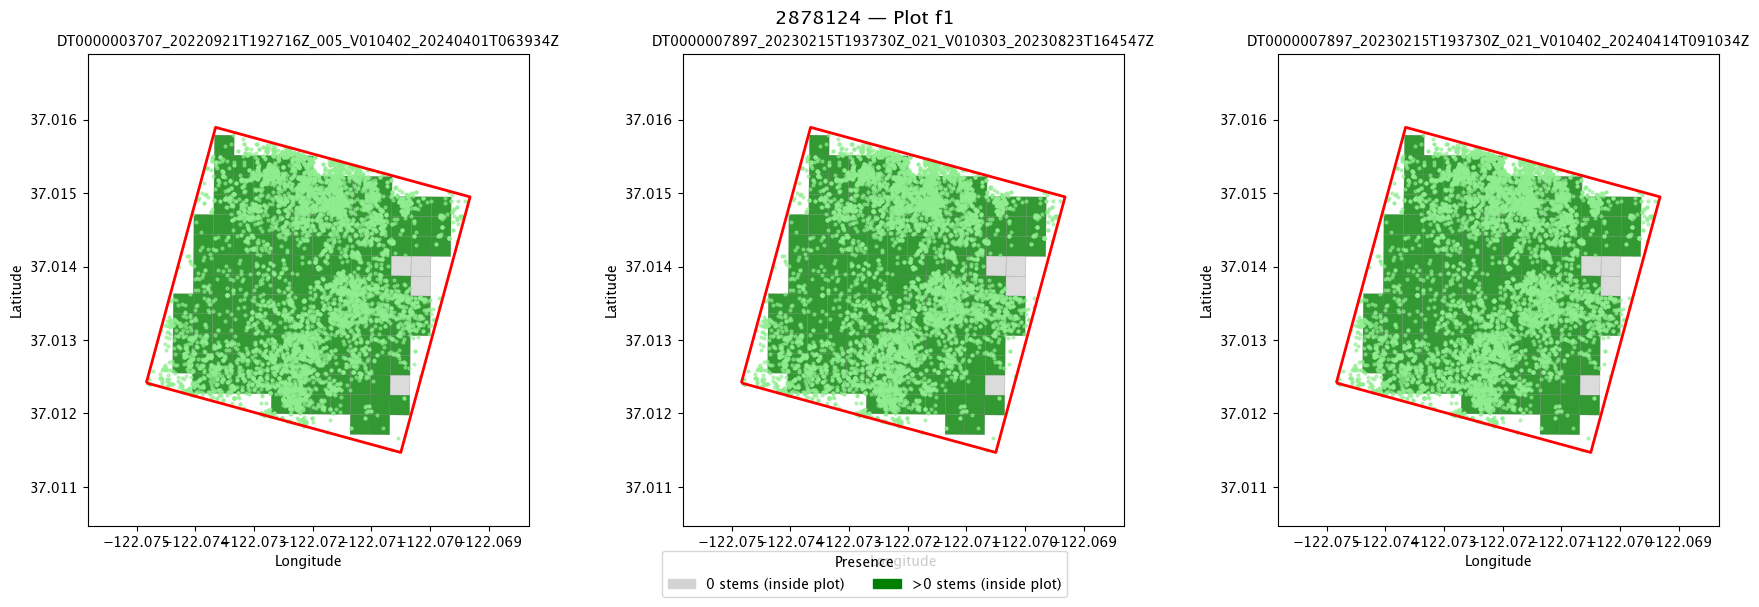

In [8]:

gridder.plot_species_grid(
    plot_id="f1",
    species="2878124",
)
plt.show()